##Sum up with a graph

Small dataset

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# data

# The major part of the data regarding MobilityPandas with from_instants have not been measured, so a zero is let.

data_calc = { # From a TrajectoryCollection. Time in seconds
    # of the form: (MovingPandas, MobilityPandas, MobilityPandas with from_arrays, PyMEOS)
    "basic Douglas-Peucker s": (3.621, 5.14, 4.7, 0.013),
    "basic Douglas-Peucker m": (15.59, 31.59, 26.85, 0.081),
    "basic Douglas-Peucker b": (89.65, 130.8, 106.62, 0.45),
    # "basic Douglas-Peucker o": (1.943834, 0, 1.897813, 0.000822), one trajectory
    "basic Douglas-Peucker t": (200.457250, 0, 41.426111, 0.103859),
    "Douglas-Peucker\n with time consideration s": (22.921, 5.48, 4.937, 0.033),
    "Douglas-Peucker\n with time consideration m": (283.67, 34.455, 29.139, 0.473),
    "Douglas-Peucker\n with time consideration b": (1560.216, 144.07, 119.789, 2.936),
    "Douglas-Peucker\n with time consideration t": (400.182531, 0, 69.384674, 0.832152),
    "Hausdorff distance s": (1.284, 0, 1.348, 0.038),
    "Hausdorff distance m": (9.091, 0, 5.778, 0.541),
    "Hausdorff distance b": (45.352, 0, 18.803, 5.964),
    "Hausdorff distance t": (597.292602, 0, 30.933045, 26.121176),
    "Minimum distance s": (3.437, 0, 5.049, 0.015),
    "Minimum distance m": (10.177, 0, 29.61, 0.056),
    "Minimum distance b": (15.542, 0, 79.845, 0.128),
    "Minimum distance t": (133.646902, 0, 105.666674, 0.033539),
    "Minimum time delta s": (4.965, 0, 5.375198, 0.018),
    "Minimum time delta m": (19.516, 0, 29.431826, 0.052),
    "Minimum time delta b": (65.673, 0, 122.568823, 0.175),
    "Minimum time delta t": (19.234110, 0, 55.598952, 0.016928),
}

data_mem = { # of the form: (MovingPandas, MobilityPandas, MobilityPandas with from_arrays, PyMEOS). Memory in MiB
    "basic Douglas-Peucker s": (25.625, 0, 0, 0.0),
    "basic Douglas-Peucker m": (50.25, 0, 0, 0.0),
    "basic Douglas-Peucker b": (57.875, 0, 0, 0.75),
    "basic Douglas-Peucker t": (9.81, 0, 38.62, 0.0),
    "Douglas-Peucker\n with time consideration s": (0.375, 21.625, 24, 0.125),
    "Douglas-Peucker\n with time consideration m": (21.625, 43, 66.5, 0.125),
    "Douglas-Peucker\n with time consideration b": (59.5, 217.62, 325.375, 17.875),
    "Douglas-Peucker\n with time consideration t": (12.55, 0, 20.84, 0.12),
    "Hausdorff distance s": (2.88, 0, 9.5, 0.0),
    "Hausdorff distance m": (9.375, 0, 68.250, 0.0),
    "Hausdorff distance b": (10.625, 0, 283.375, 0.125),
    "Hausdorff distance t": (9.72, 0, 46.75, 0.12),
    "Minimum distance s": (21.25, 0, 0, 0.0),
    "Minimum distance m": (16.625, 0, 0, 3.125),
    "Minimum distance b": (45.125, 0, 257.5, 8.25),
    "Minimum distance t": (30.12, 0, 50.23, 0),
    "Minimum time delta s": (15.625, 0, 0, 0.0),
    "Minimum time delta m": (31.375, 0, 0, 0.125),
    "Minimum time delta b": (37.5, 0, 110.250, 0.875),
    "Minimum time delta t": (18.66, 0, 14.85, 0),
}


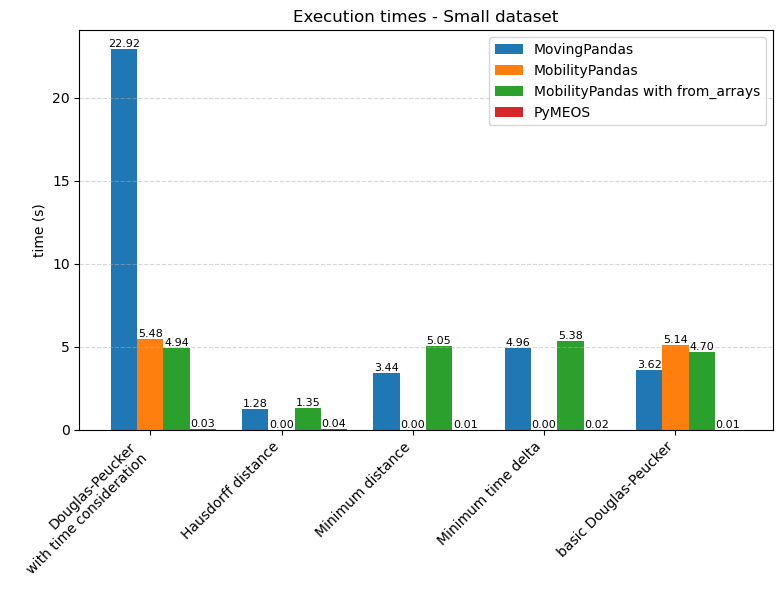

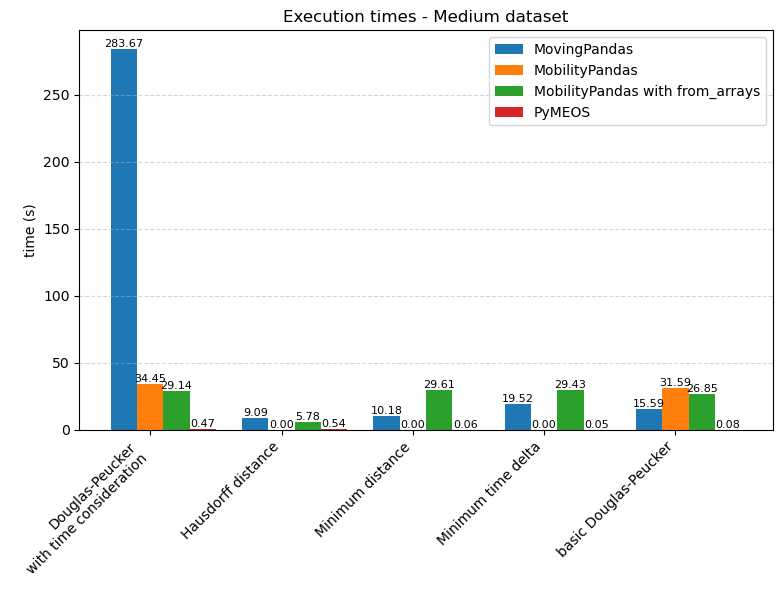

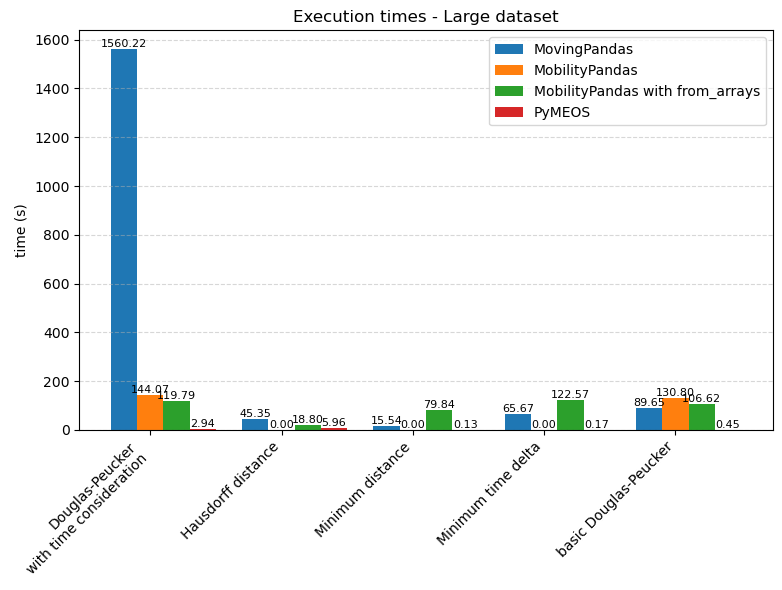

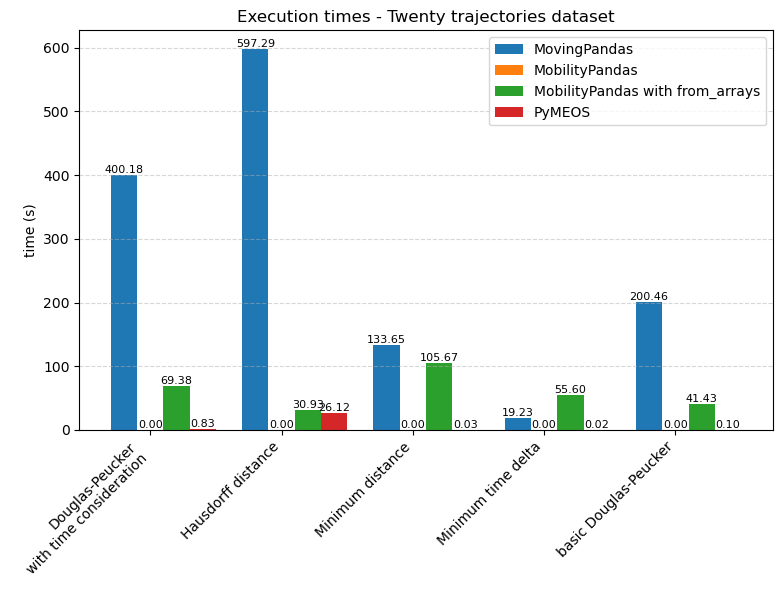

In [9]:
# global execution time graph

libraries = ["MovingPandas", "MobilityPandas", "MobilityPandas with from_arrays", "PyMEOS"]
sizes = [' s', ' m', ' b', ' t']
size_labels = ['Small', 'Medium', 'Large', 'Twenty trajectories']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

function_names = sorted({key[:-2] for key in data_calc})
x = np.arange(len(function_names))
bar_width = 0.2

for i, size in enumerate(sizes):
    plt.figure(figsize=(8, 6))

    for j in range(4):
        values = [data_calc[f + size][j] for f in function_names]
        bar_positions = x + j * bar_width
        bars = plt.bar(bar_positions, values, width=bar_width, label=libraries[j], color=colors[j])

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

    plt.title(f"Execution times - {size_labels[i]} dataset")
    plt.xticks(x + bar_width, function_names, rotation=45, ha='right')
    plt.ylabel("time (s)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


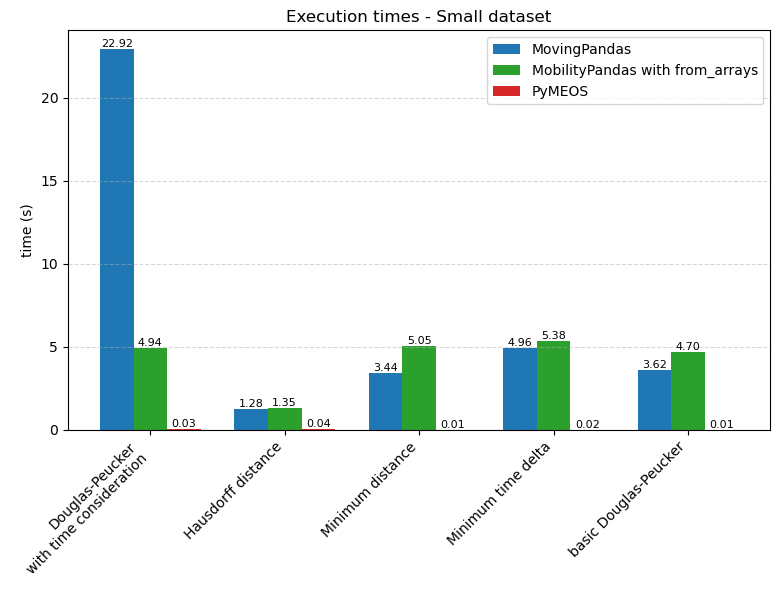

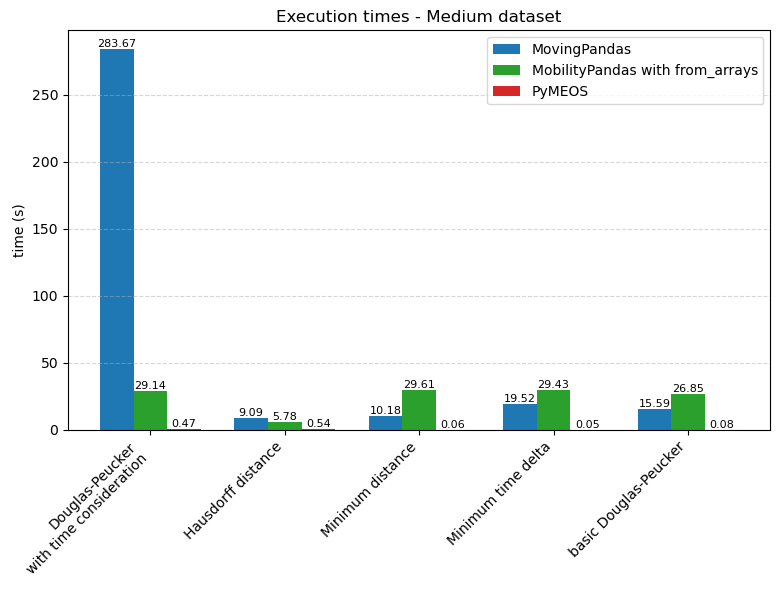

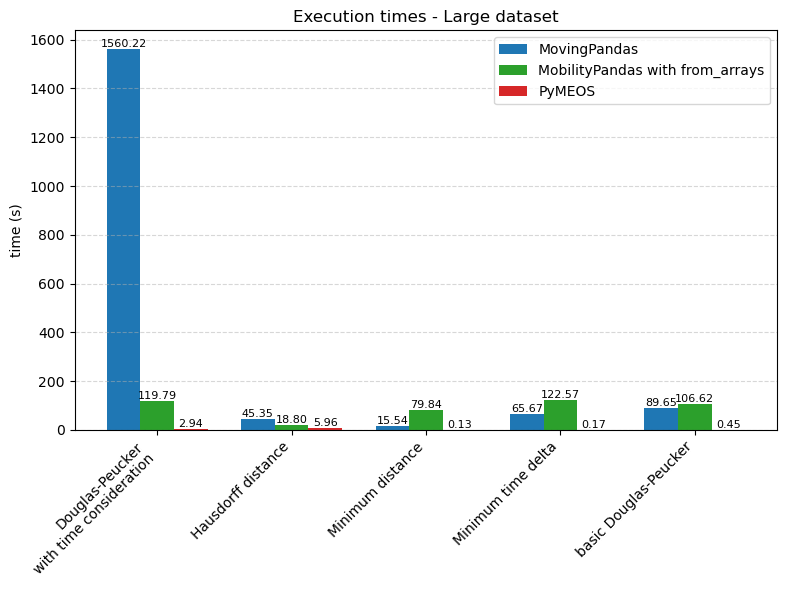

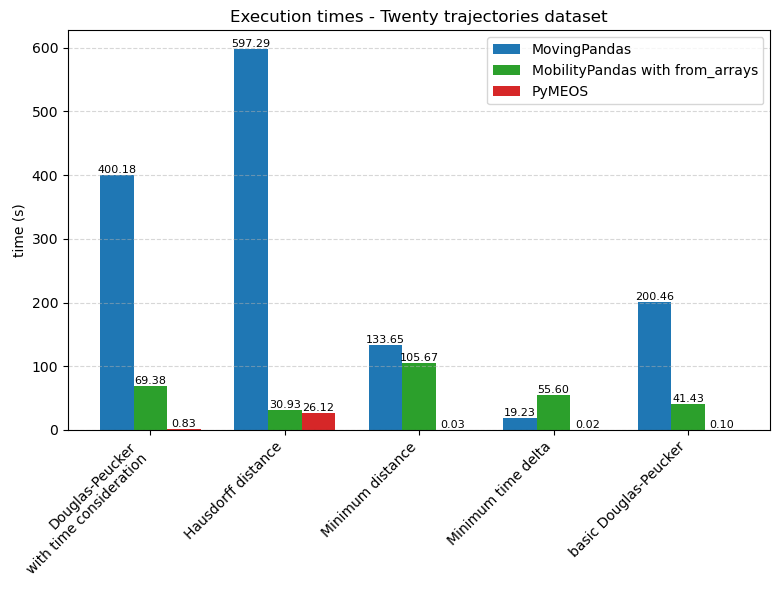

In [10]:
# without MobilityPandas (from_instants)

# global execution time graph

libraries = ["MovingPandas", "MobilityPandas with from_arrays", "PyMEOS"]
sizes = [' s', ' m', ' b', ' t']
size_labels = ['Small', 'Medium', 'Large', 'Twenty trajectories']
colors = ['tab:blue', 'tab:green', 'tab:red']

function_names = sorted({key[:-2] for key in data_calc})
x = np.arange(len(function_names))
bar_width = 0.25

for i, size in enumerate(sizes):
    plt.figure(figsize=(8, 6))

    for j in range(len(libraries)):
        values = [data_calc[f + size][[0,2,3][j]] for f in function_names]
        # [0,2,3] = MovingPandas, MobilityPandas with from_arrays, PyMEOS
        bar_positions = x + j * bar_width
        bars = plt.bar(bar_positions, values, width=bar_width, label=libraries[j], color=colors[j])

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

    plt.title(f"Execution times - {size_labels[i]} dataset")
    plt.xticks(x + bar_width, function_names, rotation=45, ha='right')
    plt.ylabel("time (s)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

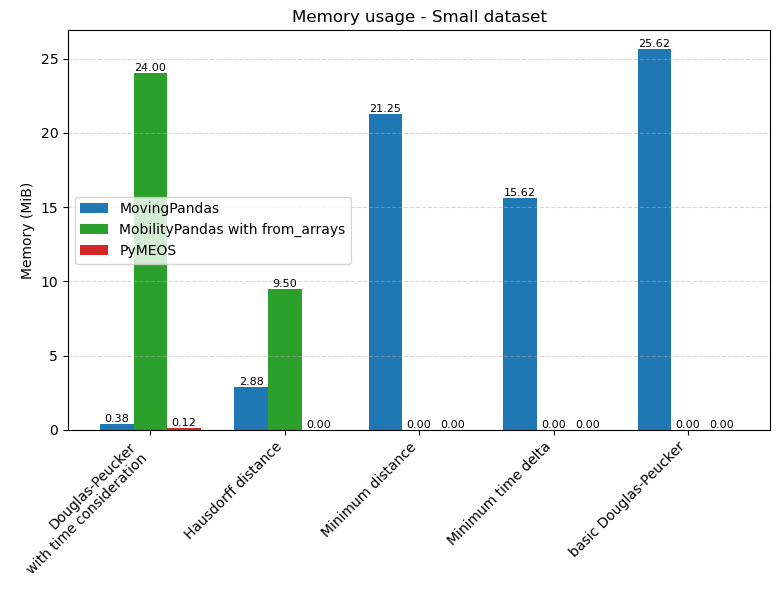

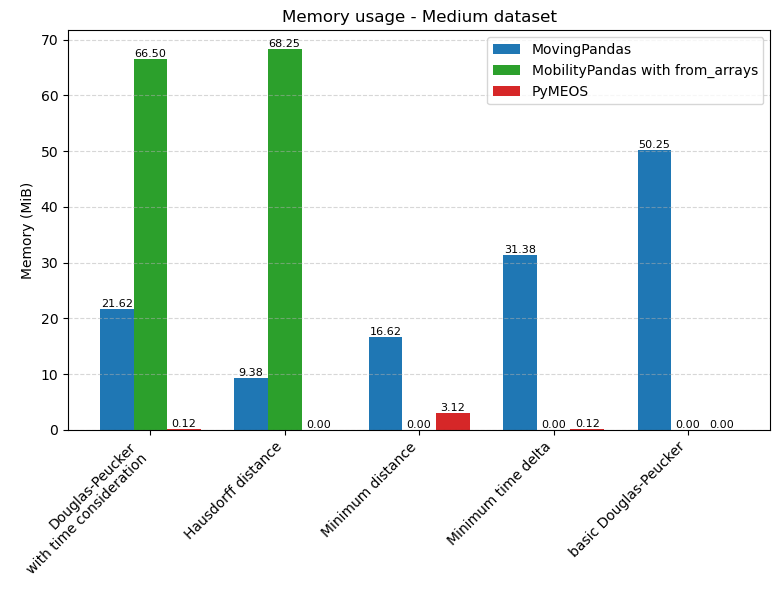

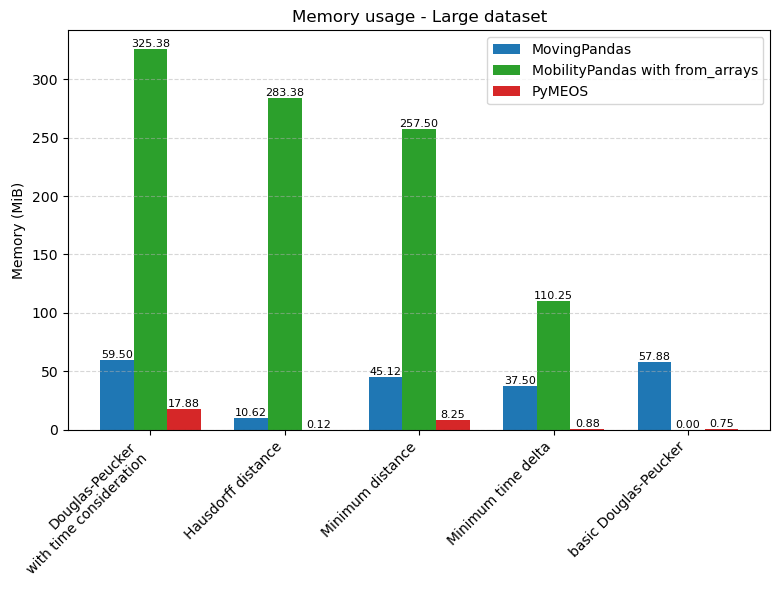

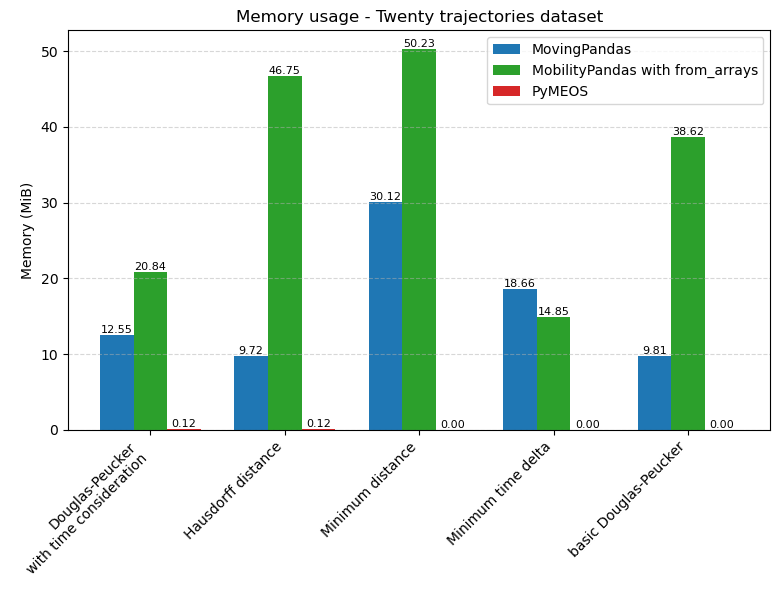

In [11]:
# global memory graph

libraries = ["MovingPandas", "MobilityPandas with from_arrays", "PyMEOS"]
sizes = [' s', ' m', ' b', ' t']
size_labels = ['Small', 'Medium', 'Large', 'Twenty trajectories']
colors = ['tab:blue', 'tab:green', 'tab:red']

function_names = sorted({key[:-2] for key in data_mem})
x = np.arange(len(function_names))
bar_width = 0.25

for i, size in enumerate(sizes):
    plt.figure(figsize=(8, 6))

    for j in range(len(libraries)):
        values = [data_mem[f + size][[0,2,3][j]] for f in function_names]
        bar_positions = x + j * bar_width
        bars = plt.bar(bar_positions, values, width=bar_width, label=libraries[j], color=colors[j])

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

    plt.title(f"Memory usage - {size_labels[i]} dataset")
    plt.xticks(x + bar_width, function_names, rotation=45, ha='right')
    plt.ylabel("Memory (MiB)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


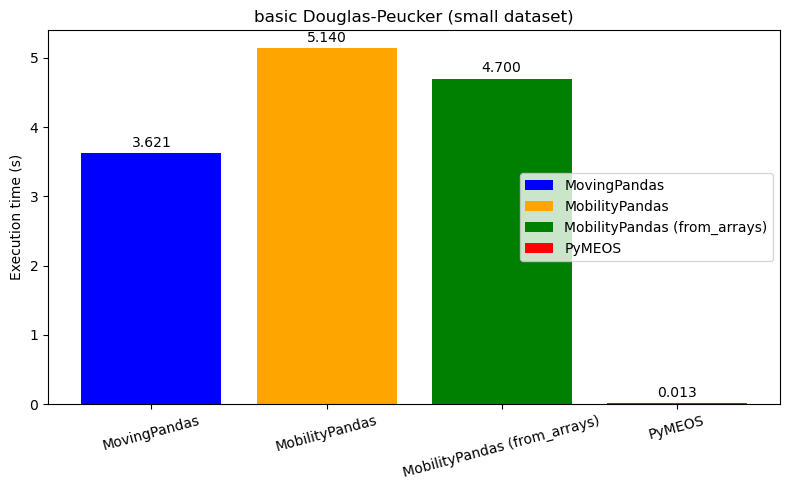

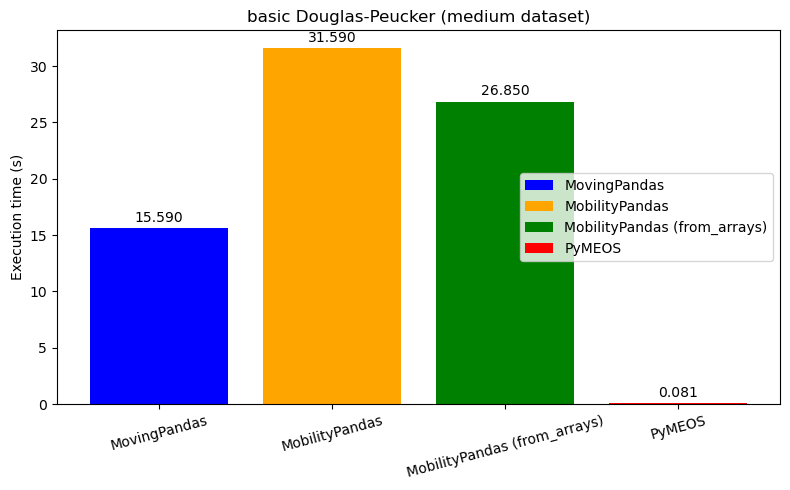

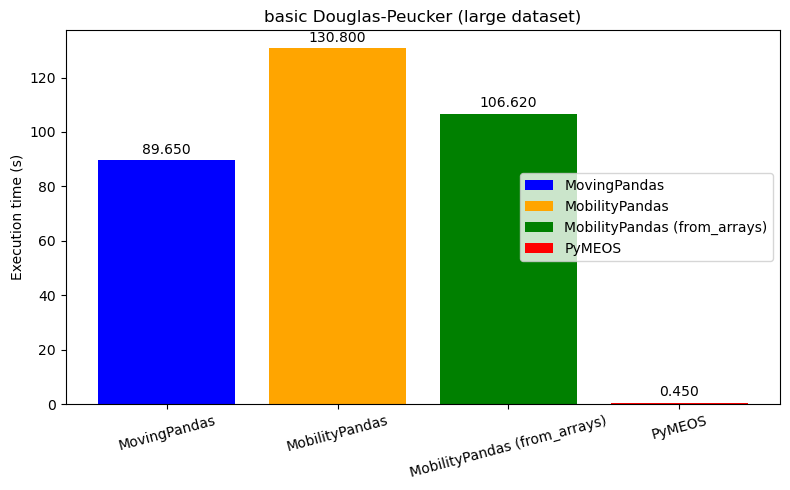

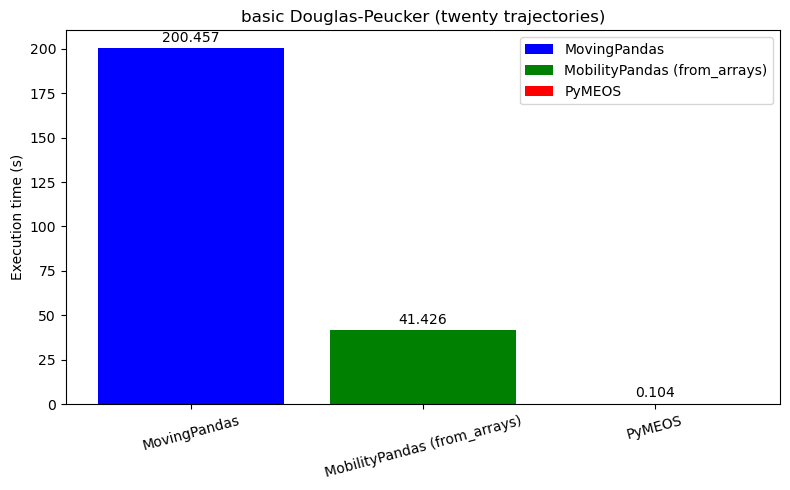

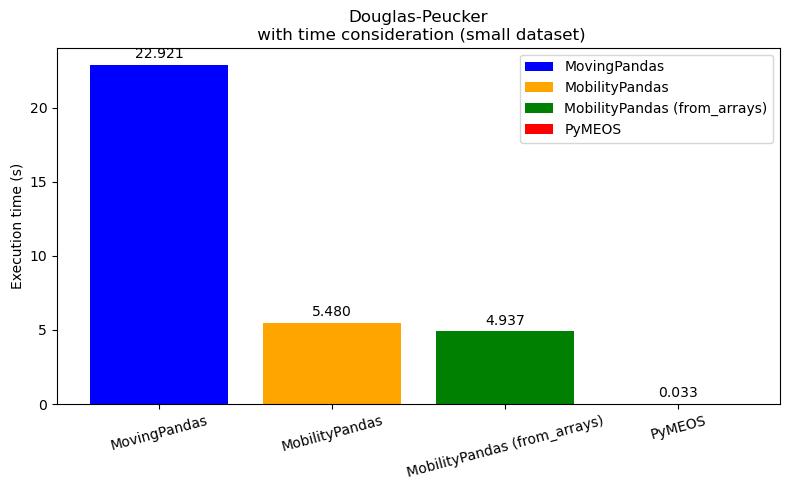

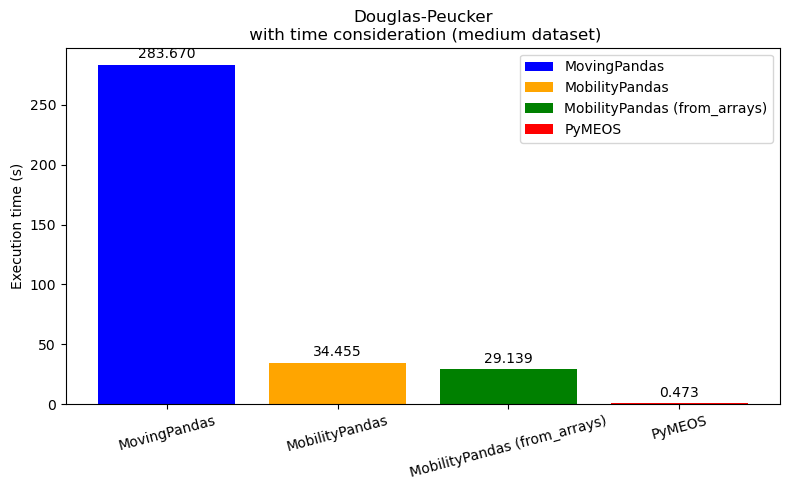

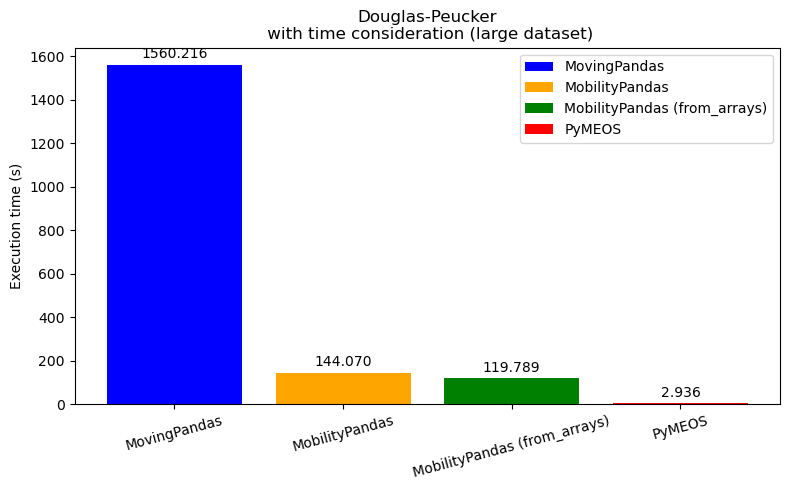

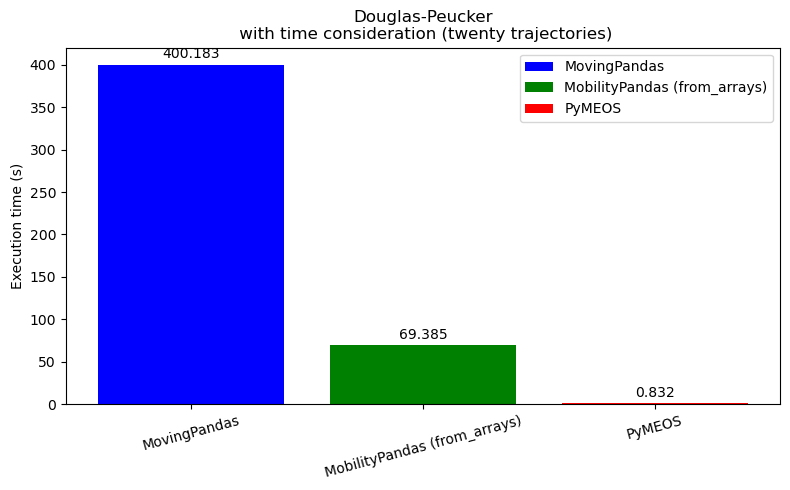

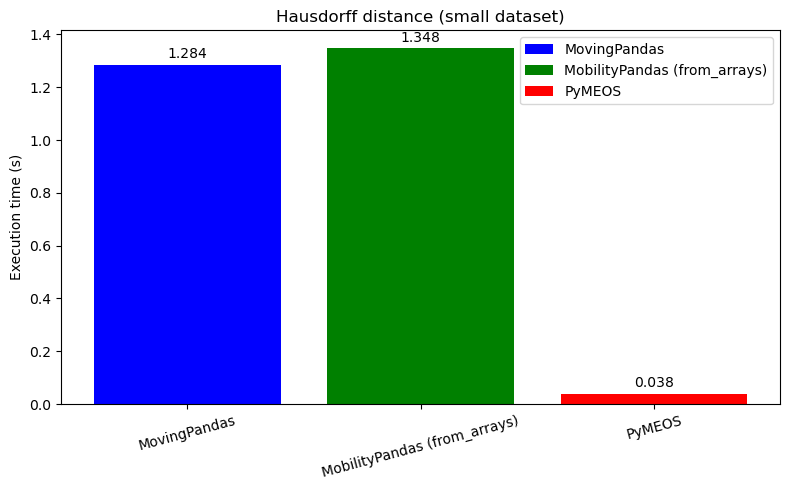

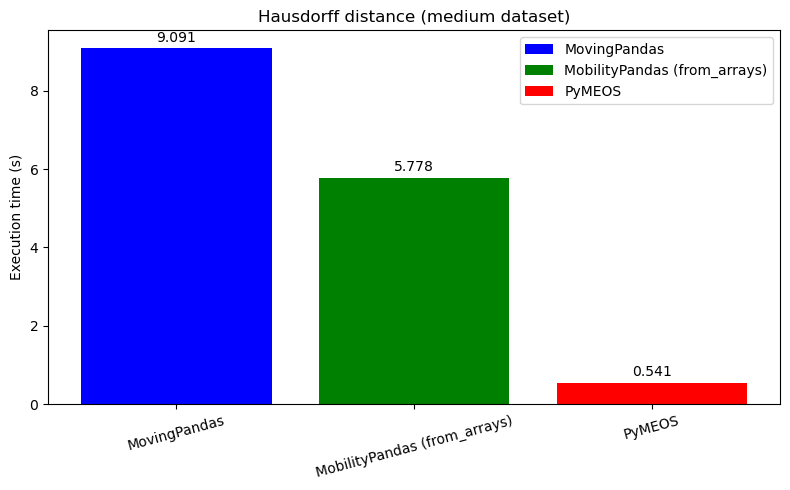

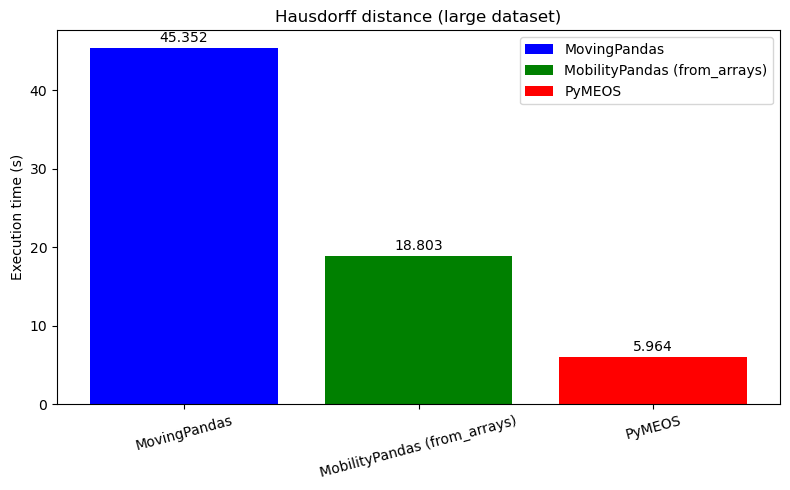

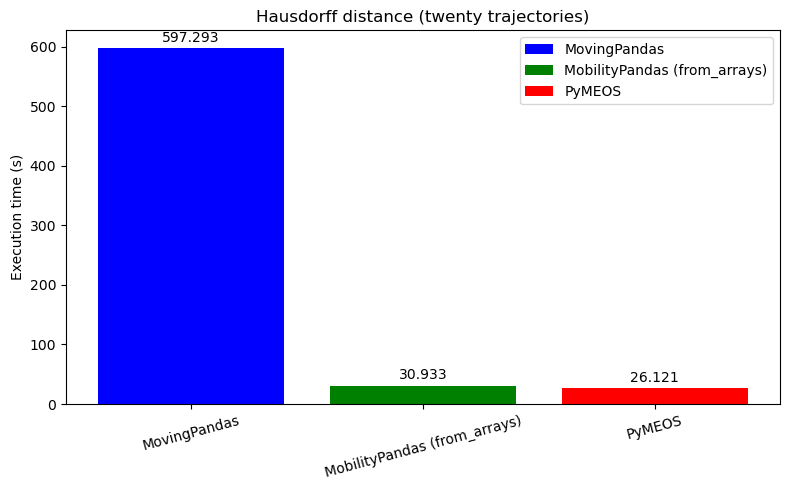

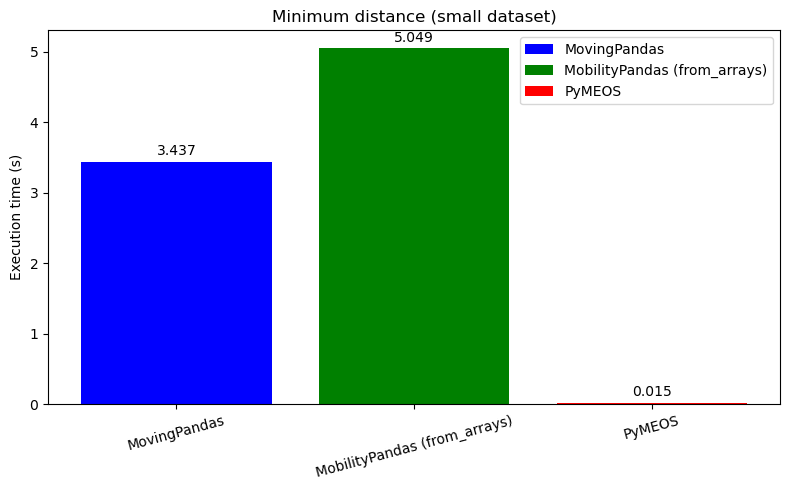

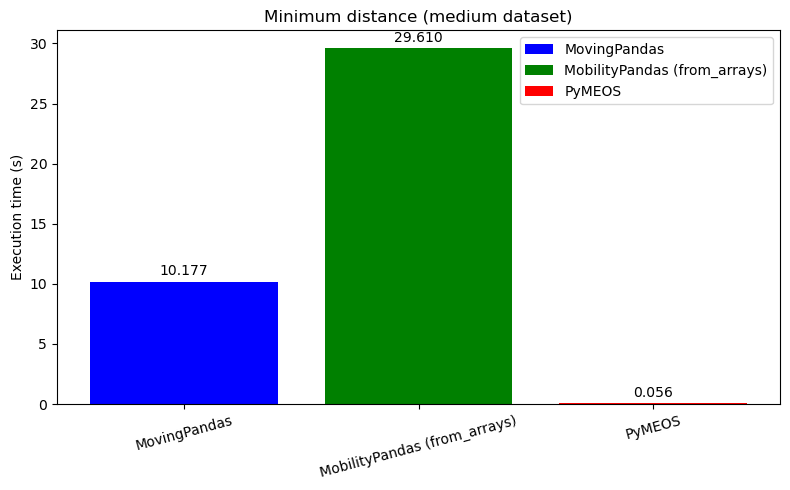

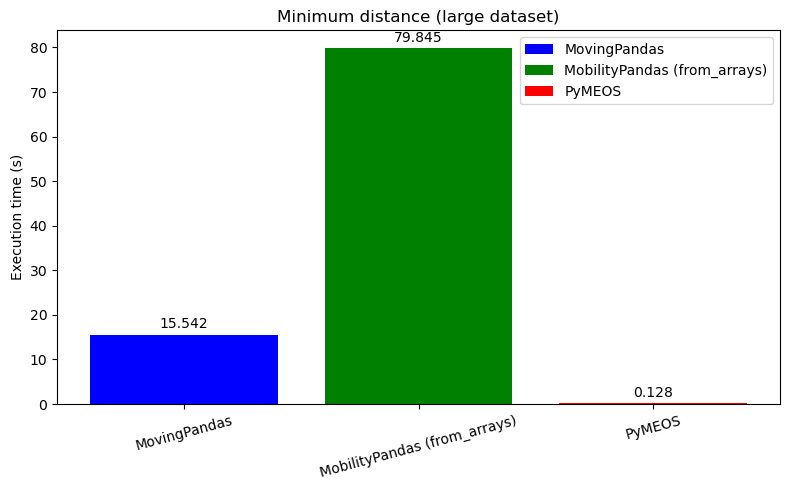

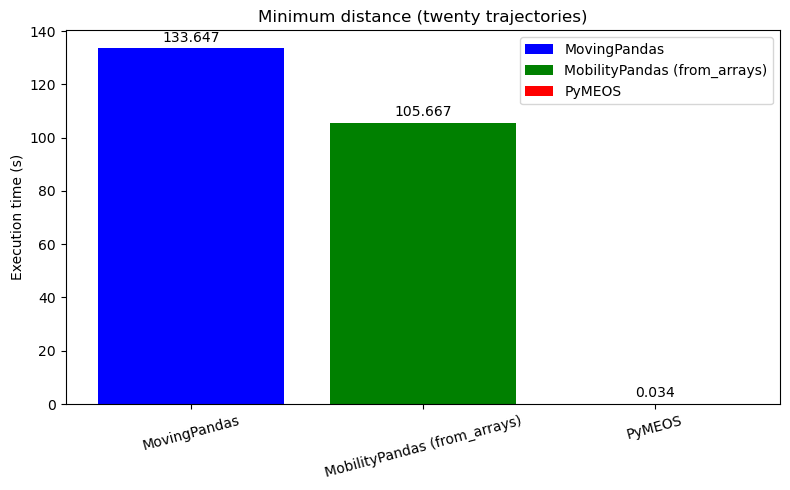

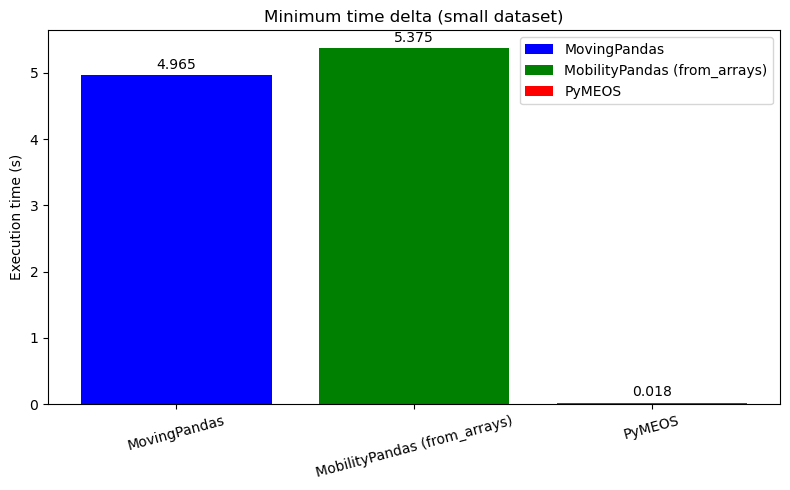

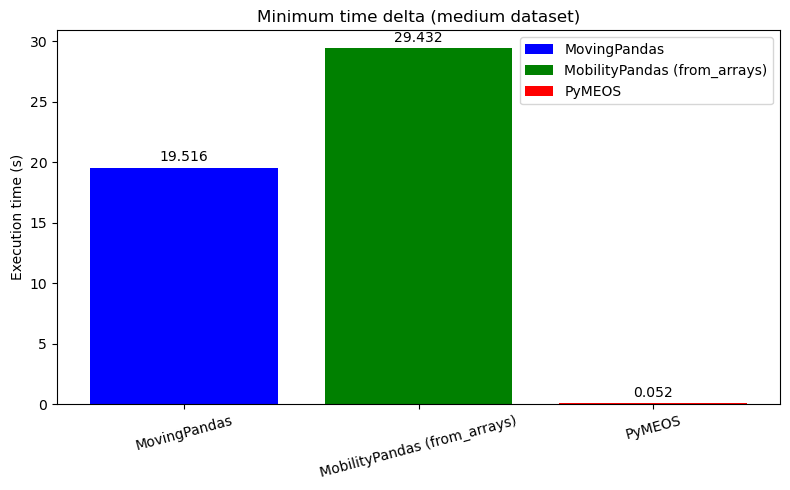

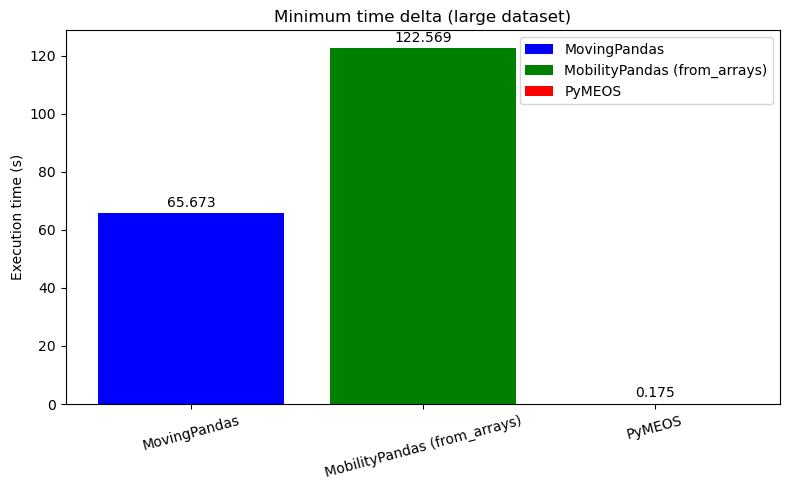

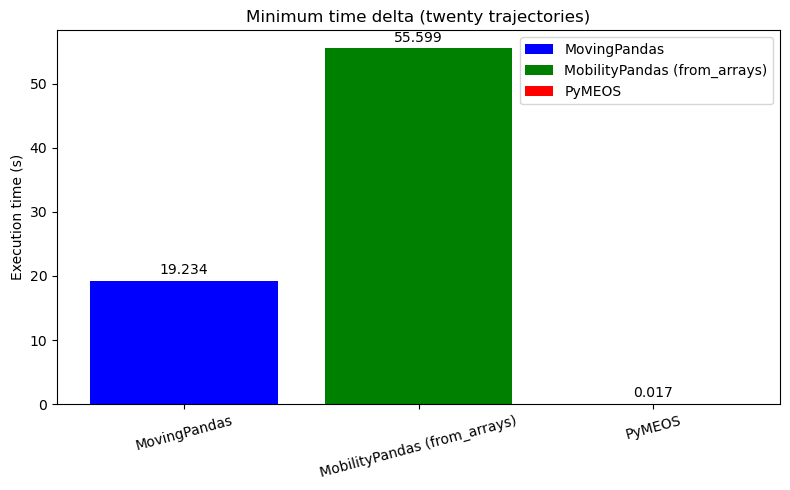

In [12]:
# individual graph

libraries = [
    ("MovingPandas", "blue"),
    ("MobilityPandas", "orange"),
    ("MobilityPandas (from_arrays)", "green"),
    ("PyMEOS", "red"),
]

replacements = {
    " s": " (small dataset)",
    " m": " (medium dataset)",
    " b": " (large dataset)",
    " t": " (twenty trajectories)"
}

def clean_label(label):
    for k, v in replacements.items():
        if label.endswith(k):
            return label[: -len(k)] + v 
    return label

for algo_dataset, values in data_calc.items():
    # don't show zero
    filtered = [(lib, color, val) for (lib, color), val in zip(libraries, values) if val > 0]
    
    if not filtered:
        continue

    libs, colors, vals = zip(*filtered)
    x = np.arange(len(libs))
    
    plt.figure(figsize=(8,5))
    bars = []
    for i in range(len(libs)):
        bar = plt.bar(x[i], vals[i], color=colors[i])
        bars.append(bar)
        plt.text(
            x[i],
            vals[i] + max(vals)*0.01,
            f"{vals[i]:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.ylabel("Execution time (s)")
    plt.title(clean_label(algo_dataset))
    plt.xticks(x, libs, rotation=15)
    plt.legend(bars, libs)
    plt.tight_layout()
    plt.show()
